In [1]:
try:
    import ydf
except:
    %pip install -q -U ydf
    import ydf

print(f"ydf version: {ydf.__version__}")

ydf version: 0.15.0


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, label_binarize
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
train[NUMS].describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


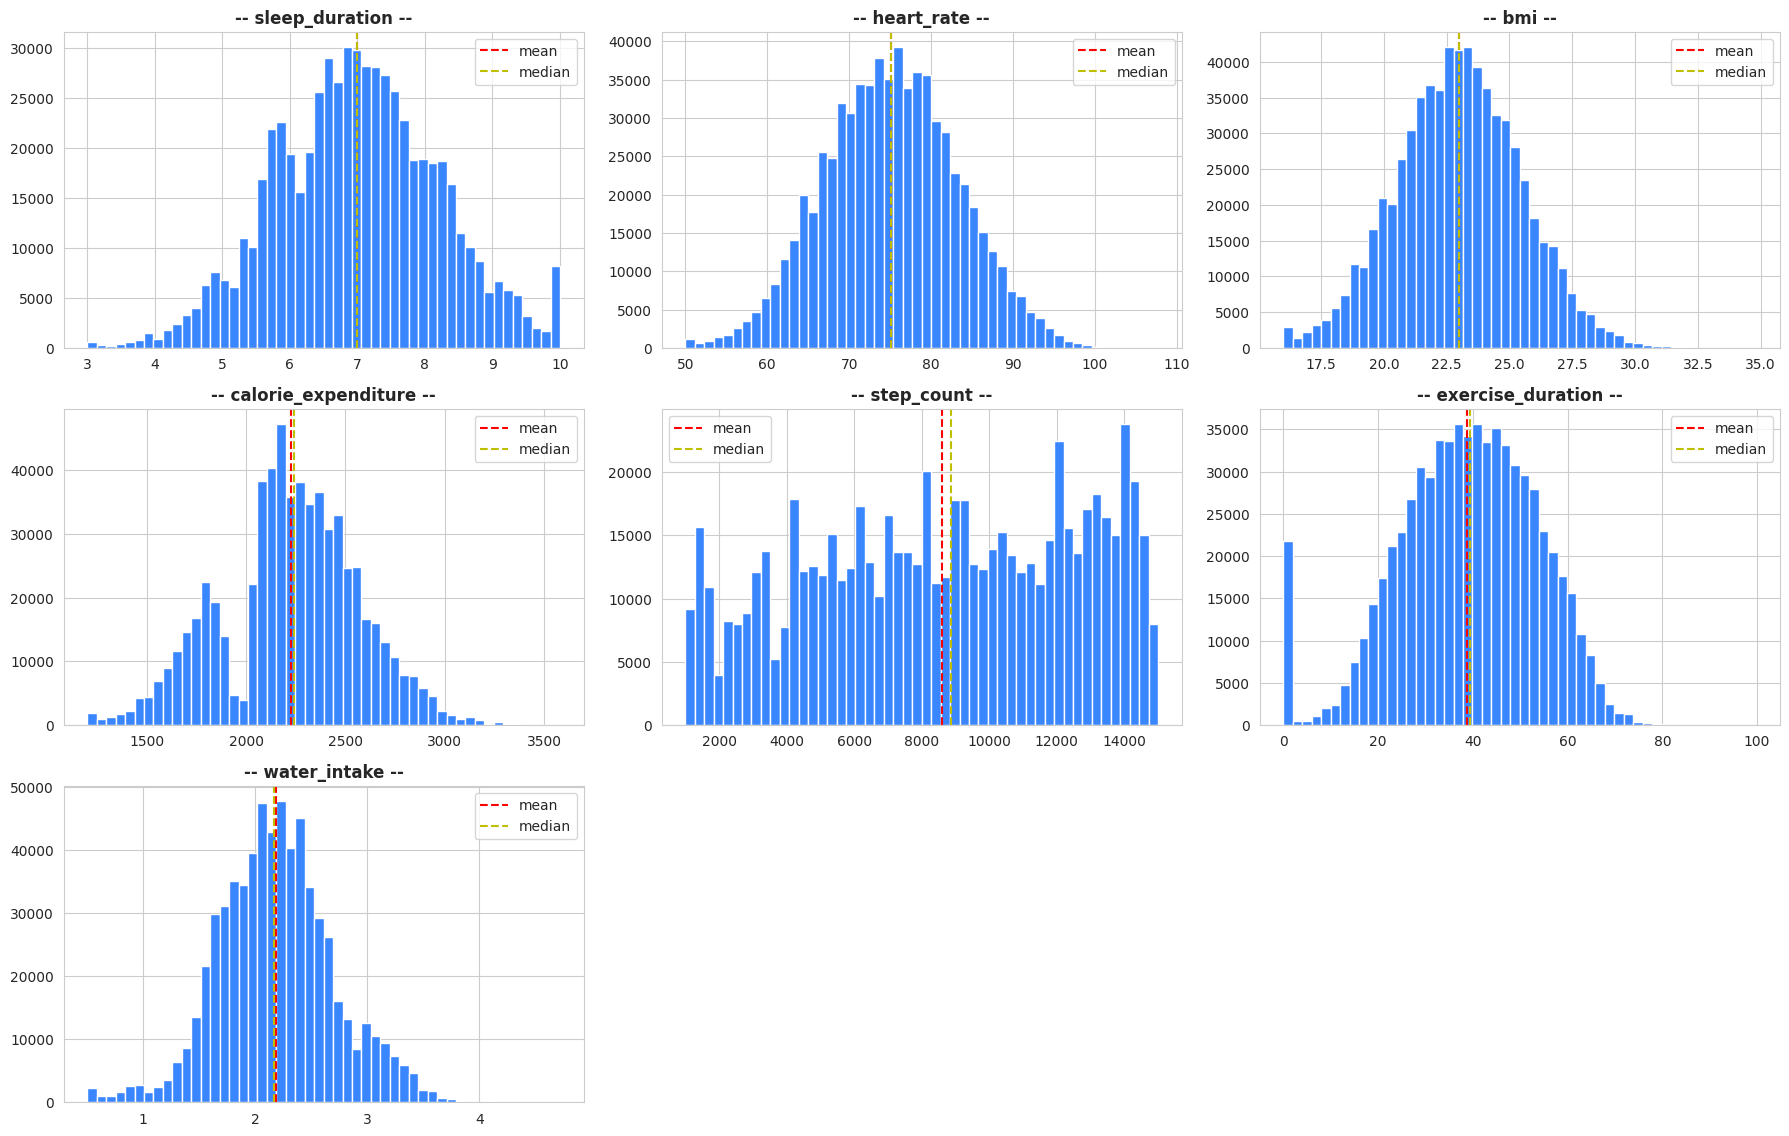

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'-- {col} --', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

diet_type                      3
physical_activity_level        3
sleep_quality                  3
gender                         3
smoking_alcohol                3
stress_level                   3
water_intake                 400
heart_rate                   537
sleep_duration               701
exercise_duration            856
bmi                         1596
calorie_expenditure         2101
step_count                 12807
dtype: int64

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight('balanced', classes=cls_, y=y)
    return dict(zip([str(c) for c in cls_], wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
get_class_weights(train[TARGET])

{'0': np.float64(5.779195873007898),
 '1': np.float64(0.38819519565636845),
 '2': np.float64(3.9849860254544613)}

## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['delta']:
#     print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [100]:
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
# _extract_cols = ['RaceProgress'] # , 'LapTime_Delta'

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [0, -1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [-1, 0]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     print(f"\nCreating value-based E_BINS... ", end='')
#     for b in [5]:
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [5]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Arithmetic interaction --
# BANDS = ['u', 'g', 'r', 'i', 'z']
# COLOR_PAIRS = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
#     ('r', 'i'),
# ]

# for df in tqdm([train, test, orig]):
#     for a, b in COLOR_PAIRS:
#         df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

#     for band in BANDS:
#         # df[f"_div_{band}_redshift"] = (df[band] / (df['redshift'] + 1e-6)).astype('float32')
#         df[f"_div_abs_{band}_redshift"] = (df[band] / (df['redshift'].abs() + 1e-6)).astype('float32')

#     df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
#     df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

In [19]:
# ## -- Cyclical extraction --
# for df in tqdm([train, test, orig]):
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in tqdm([train, test, orig]):
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [20]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [21]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(f"{n}.. ", end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")
# train[freq_cols].describe()

In [22]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

In [25]:
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
## -- Get NaN indicators --
def appy_nan_indicator(df):
    df1 = df.copy()
    cols_with_nan = df1.columns[df1.isna().any()]
    indicators = df1[cols_with_nan].isna().astype(int).add_prefix('isna_')
    indi_cols = indicators.columns.tolist()
    df1 = df1.join(indicators)

    return df1, indi_cols

train, INDI_COLS = appy_nan_indicator(train)
test, _  = appy_nan_indicator(test)
orig, _  = appy_nan_indicator(orig)

# ## -- Fill categorical --
# train[CATS] = train[CATS].fillna('missing')
# test[CATS]  = test[CATS].fillna('missing')
# orig[CATS]  = orig[CATS].fillna('missing')

print(INDI_COLS)
train

['isna_sleep_duration', 'isna_heart_rate', 'isna_bmi', 'isna_calorie_expenditure', 'isna_step_count', 'isna_exercise_duration', 'isna_water_intake', 'isna_diet_type', 'isna_stress_level', 'isna_sleep_quality', 'isna_physical_activity_level', 'isna_smoking_alcohol', 'isna_gender']


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0,0,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0,0,0,0,1,0,0,0,0,0,0,0,0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0,0,0,0,0,0,0,0,0,0,0,0,0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,0,0,0,0,0,0,0,0,1,0,0,0,0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,0,0,0,0,0,0,0,0,1,0,0,0,0


In [27]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [28]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 26


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0,0,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0,0,0,0,1,0,0,0,0,0,0,0,0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0,0,0,0,0,0,0,0,0,0,0,0,0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,0,0,0,0,0,0,0,0,1,0,0,0,0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,0,0,0,0,0,0,0,0,1,0,0,0,0


# ML TRAINING

In [29]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()

!pip show venn_abers

  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.

Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [30]:
# def Trainer_CV(
#     model_name, params, train_df, test_df, features, target,
#     kfold, cat_cols, verbosity, use_weights=False, calibrate=False):
#     print(f"\n===== Starting CV: {model_name} =====")
#     start = time()

#     X = train_df[features]
#     y = train_df[target]
    
#     num_cls = y.nunique()
    
#     oof_preds = np.zeros((len(X), num_cls))
#     test_preds = np.zeros((len(test_df), num_cls))

#     fold_scores = []
#     brier_scores = []

#     for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
#         print(f"\n#### FOLD {idx+1}/{kfold.n_splits} | {get_system_info()} | ", end='')

#         # Split data for the current fold
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test_df[features].copy()

#         ## -- OPTION A: Concatenate original data --
#         # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # ## -- Target Encoding --
#         # te_cols = INTER
#         # print(f" • Target Encoding {len(te_cols)} features... ")
#         # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

#         # ## -- TE Opt1. -> Using custom script --
#         # te_enc = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
#         # X_train = te_enc.fit_transform(X_train, y_train)
#         # X_valid = te_enc.transform(X_valid)
#         # X_test  = te_enc.transform(X_test)

#         # cm_enc  = CategoryMeanTransformer(cat_cols=ROUNDS)
#         # X_train = cm_enc.fit_transform(X_train, y_train)
#         # X_valid = cm_enc.transform(X_valid)
#         # X_test  = cm_enc.transform(X_test)

#         # combined = pd.concat([X_train, X_valid, X_test])
#         # for c in cats:
#         #     combined[c] = combined[c].astype(str) #.astype('category')

#         # X_train = combined.iloc[:len(X_train)]
#         # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
#         # X_test  = combined.iloc[len(X_train)+len(X_valid):]

#         print(f"Train shape: {X_train.shape} -")

#         ## -- Internal Split for Calibration --
#         X_base, X_calib, y_base, y_calib = train_test_split(
#             X_train, y_train, train_size=0.75, stratify=y_train, random_state=CFG['SEED']
#         )

#         if calibrate:
#             # ## -- To enable ydf read numerical as categories --
#             # flat_features = []
#             # for f in cats: 
#             #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

#             print(f" • Training ydf model {X_base.shape}... ")
#             ## -- Build YDF model --
#             model = ydf.GradientBoostedTreesLearner(
#                 **params,
#                 label=target,
#                 class_weights=get_class_weights(y_train) if use_weights else None,
#                 # features=flat_features,   # 1. Semantic for categories goes here
#                 # include_all_columns=True, # 2. Include all features for training
#             ).train(
#                 ds=pd.concat([X_base, y_base], axis=1),
#                 valid=pd.concat([X_valid, y_valid], axis=1),
#                 verbose=verbosity,
#             )

#             ydf_acc   = balanced_acc(y_valid, model.predict(X_valid))
#             ydf_brier = multi_class_brier(y_valid, model.predict(X_valid), np.unique(y_valid))

#             ## -- Calibrate outputs --
#             print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
#             vao = VennAbersCalibrator() # - Get OOF predictions -
#             venn_oof_preds = vao.predict_proba(
#                 p_cal   = model.predict(X_calib),
#                 y_cal   = y_calib.to_numpy(),
#                 p_test  = model.predict(X_valid),
#                 va_type = 'one_vs_all',
#             )
#             oof_preds[val_idx] = venn_oof_preds

#             vat = VennAbersCalibrator() # - Get TEST predictions -
#             venn_test_preds = vat.predict_proba(
#                 p_cal   = model.predict(X_calib),
#                 y_cal   = y_calib.to_numpy(),
#                 p_test  = model.predict(X_test),
#                 va_type = 'one_vs_all',
#             )

#             test_preds += venn_test_preds

#             ## -- Fold scores --
#             fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#             fold_scores.append(fold_score)
#             brier_scores.append(brier_score)
#             print(f"{CFG['YELLOW']} • Fold {idx+1}")
#             print(f"base_acc:  {ydf_acc:.5f} | base_brier:  {ydf_brier:.5f}")
#             print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
#             print(f"{CFG['RESET']}")
#         else:
#             # ## -- To enable ydf read numerical as categories --
#             # flat_features = []
#             # for f in cats: 
#             #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

#             ## -- Build YDF model --
#             model = ydf.GradientBoostedTreesLearner(
#                 **params,
#                 label=target,
#                 class_weights=get_class_weights(y_train) if use_weights else None,
#                 # features=flat_features,   # 1. Semantic for categories goes here
#                 # include_all_columns=True, # 2. Include all features for training
#             ).train(
#                 ds=pd.concat([X_train, y_train], axis=1),
#                 valid=pd.concat([X_valid, y_valid], axis=1),
#                 verbose=verbosity,
#             )

#             ## -- Predict on val and test sets --
#             oof_preds[val_idx] = model.predict(X_valid)
#             test_preds += model.predict(X_test)

#             ## -- Calculate and print fold score --
#             fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
#             brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

#             fold_scores.append(fold_score)
#             brier_scores.append(brier_score)
#             print(f"{CFG['YELLOW']} • Fold {idx+1} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

#         # ## -- Clean up memory --
#         # del y_train, y_valid, X_test
#         # gc.collect() 

#     ## -- Average the test predictions --
#     test_preds /= kfold.n_splits

#     ## -- CV results --
#     print("\n==================================================")
#     print(f"{kfold.n_splits}-FOLD CV: {model_name}")
#     print("==================================================")
#     for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
#         print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

#     ## -- Final out-of-fold score --
#     oof_score = np.round(balanced_acc(y, oof_preds), 5)
#     oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

#     print("-------------------------------------------------|")
#     print(f"OOF score: {oof_score}")
#     print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f"OOF brier: {oof_brier}")
#     print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'scores': oof_score,
#         'model': model,
#         'data': pd.concat([X_valid, y_valid], axis=1), 
#     }

# print("⚙️ Training function ready ⚙️")

In [31]:
## -- MULTI-SEEDS --

def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kfold,
    multi_seeds=[42, 111, 0], cat_cols=None, verbosity=1, use_weights=False, calibrate=False):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]
    
    num_cls = y.nunique()
    
    oof_preds = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    fold_scores = []
    brier_scores = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y), 1):
        print(f"\n#### FOLD {idx}/{kfold.n_splits} | {get_system_info()} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        oof_seeds  = np.zeros((len(X_valid), num_cls))
        test_seeds = np.zeros((len(X_test), num_cls))

        ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- Target Encoding --
        # te_cols = INTER
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        # ## -- TE Opt1. -> Using custom script --
        # te_enc = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # cm_enc  = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str) #.astype('category')

        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} -")

        ## -- Internal Split for Calibration --
        X_base, X_calib, y_base, y_calib = train_test_split(
            X_train, y_train, train_size=0.75, stratify=y_train, random_state=CFG['SEED']
        )

        if calibrate:
            # ## -- To enable ydf read numerical as categories --
            # flat_features = []
            # for f in cats: 
            #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

            print(f" • Training ydf model {X_base.shape}... ")
            ## -- Build YDF model --
            model = ydf.GradientBoostedTreesLearner(
                **params,
                label=target,
                class_weights=get_class_weights(y_train) if use_weights else None,
                # features=flat_features,   # 1. Semantic for categories goes here
                # include_all_columns=True, # 2. Include all features for training
            ).train(
                ds=pd.concat([X_base, y_base], axis=1),
                valid=pd.concat([X_valid, y_valid], axis=1),
                verbose=verbosity,
            )

            ydf_acc   = balanced_acc(y_valid, model.predict(X_valid))
            ydf_brier = multi_class_brier(y_valid, model.predict(X_valid), np.unique(y_valid))

            ## -- Calibrate outputs --
            print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
            vao = VennAbersCalibrator() # - Get OOF predictions -
            venn_oof_preds = vao.predict_proba(
                p_cal   = model.predict(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict(X_valid),
                va_type = 'one_vs_all',
            )
            oof_preds[val_idx] = venn_oof_preds

            vat = VennAbersCalibrator() # - Get TEST predictions -
            venn_test_preds = vat.predict_proba(
                p_cal   = model.predict(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict(X_test),
                va_type = 'one_vs_all',
            )

            test_preds += venn_test_preds

            ## -- Fold scores --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

            fold_scores.append(fold_score)
            brier_scores.append(brier_score)

            print(f"{CFG['YELLOW']} • Fold {idx}")
            print(f"base_acc:  {ydf_acc:.5f} | base_brier:  {ydf_brier:.5f}")
            print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
            print(f"{CFG['RESET']}")
        else:
            for i, seed in tqdm(enumerate(multi_seeds), total=len(multi_seeds), desc="Training seeds"):
                print(f"Training with seed -> {seed}")
                params['random_seed'] = seed

                ## -- Shuffle X_train --
                full_train = pd.concat([X_train, y_train], axis=1)
                shuffled_full_train = full_train.sample(frac=1.0, random_state=seed)
                X_train_1 = shuffled_full_train.iloc[:, :-1].copy()
                y_train_1 = shuffled_full_train.iloc[:, -1].copy()
                ## -----------------------------------------------------------------------------
                # ## -- To enable ydf read numerical as categories --
                # flat_features = []
                # for f in cats: 
                #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))
    
                ## -- Build YDF model --
                model = ydf.GradientBoostedTreesLearner(
                    **params,
                    label=target,
                    class_weights=get_class_weights(y_train) if use_weights else None,
                    # features=flat_features,   # 1. Semantic for categories goes here
                    # include_all_columns=True, # 2. Include all features for training
                ).train(
                    ds=pd.concat([X_train_1, y_train_1], axis=1),
                    valid=pd.concat([X_valid, y_valid], axis=1),
                    verbose=verbosity,
                )

                oof_seeds  += model.predict(X_valid)
                test_seeds += model.predict(X_test)
                print(f"\tSeed ({seed}) score: {balanced_acc(y_valid, model.predict(X_valid)):.5f}")

            ## -- Predict on val and test sets --
            oof_preds[val_idx] = oof_seeds / len(multi_seeds)
            test_preds += test_seeds / len(multi_seeds)

            ## -- Calculate and print fold score --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

            fold_scores.append(fold_score)
            brier_scores.append(brier_score)

            print(f"{CFG['YELLOW']}Fold {idx} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")
            # ----------------------------------------------------------------------------------------

        # ## -- Clean up memory --
        # del y_train, y_valid, X_test
        # gc.collect() 

    ## -- Average the test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'model': model,
        'data': pd.concat([X_valid, y_valid], axis=1), 
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


### HYPER_SPACE_SEARCH

In [32]:
get_class_weights(train[TARGET])

{'0': np.float64(5.779195873007898),
 '1': np.float64(0.38819519565636845),
 '2': np.float64(3.9849860254544613)}

In [33]:
all_predictions = {}

MULTI_SEEDS = [42, 777, 1234, 24611, 0]
ALL_CATS = CATS + INDI_COLS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
USE_CALIBATOR  = False

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,isna_sleep_duration,isna_heart_rate,isna_bmi,isna_calorie_expenditure,isna_step_count,isna_exercise_duration,isna_water_intake,isna_diet_type,isna_stress_level,isna_sleep_quality,isna_physical_activity_level,isna_smoking_alcohol,isna_gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0,0,0,0,0,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female,0,0,0,0,1,0,0,0,0,0,0,0,0
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male,0,0,0,0,0,0,0,0,0,0,0,0,0
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male,0,0,0,0,0,0,0,0,1,0,0,0,0
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male,0,0,0,0,0,0,0,0,1,0,0,0,0


In [34]:
# %%time

# ## -- Search HPO space for 'LOCAL' & 'BEST_FIRST_GLOBAL' --

# tuner = ydf.RandomSearchTuner(num_trials=20, automatic_search_space=False)
# # tuner.choice('num_trees', [5000, 2000])
# # tuner.choice('shrinkage', [0.02, 0.05]) 
# # tuner.choice('subsample', [0.9, 1.0])
# tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'RANDOM', 'ONE_HOT'
# # tuner.choice('l2_regularization', [0.05, 0.1, 0.2, 0.5, 1.0])

# ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
# local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
# local_subspace.choice('max_depth', [4, 6, 8])

# # ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
# global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
# # global_subspace.choice('max_num_nodes', [None, 32, 64, 128])

# # ## -- Enable ydf process numeric features as categories --
# # num_as_cat = []
# # for f in CATS:
# #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

# ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#     task=ydf.Task.CLASSIFICATION,
#     label=TARGET, 
#     tuner=tuner,
#     num_trees=1000,
#     shrinkage=0.1,
#     class_weights=get_class_weights(train_data[TARGET]), ## 
#     # max_depth=4,
#     # features=num_as_cat,
#     # include_all_columns=True,
#     # l2_regularization=0.15,
#     # categorical_algorithm='RANDOM',
#     early_stopping_initial_iteration=10,
#     early_stopping_num_trees_look_ahead=50,
#     random_seed=CFG['SEED'], 
#     num_threads=os.cpu_count(), 
# ).train(train_data, verbose=1)

# ydf_HPO_model.describe()

In [35]:
# ydf_HPO_model.evaluate(x_sample2, weighted=True)

In [36]:
# ydf_HPO_model.plot_tree()

In [37]:
# optimizer_logs = ydf_HPO_model.hyperparameter_optimizer_logs()
# print("Total number of trials:", len(optimizer_logs.trials))

# # # Accessing the first trial
# # first_trial = optimizer_logs.trials[0]
# # print(f"\nFirst Trial Score (absolute): {abs(first_trial.score):.4f}")
# # print("First Trial Parameters:")
# # for param, value in first_trial.params.items():
# #     print(f"  {param}: {value}")

# # Iterate through all trials to find the best one (smallest absolute score)
# best_abs_score = float('inf') # Initialize to a very large number for minimization
# best_params = None

# for i, trial in enumerate(optimizer_logs.trials):
#     current_abs_score = abs(trial.score)
#     print(f"\nTrial {i+1}: Score (abs) = {current_abs_score:.5f}")
#     # print(f"  Parameters: {trial.params}") # Uncomment to see all parameters for each trial

#     if current_abs_score < best_abs_score:
#         best_abs_score = current_abs_score
#         best_params = trial.params

# print(f"\nBest Trial Score (abs): {best_abs_score:.5f}") 
# print("Best Trial Parameters:")
# if best_params:
#     for param, value in best_params.items():
#         print(f"  {param}: {value}")

# param_df = pd.Series(data=best_params, dtype='str', name='ydf_HPO_params')
# param_df.to_csv('ydf_best_params.csv', index=False)

# param_df

In [38]:
PARAMS = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': "LOCAL",
    # 'num_trees': 500, # DEF=300
    # 'max_depth': 6,
    # 'shrinkage': 0.08, # def=0.1
    'categorical_algorithm': "CART", # 'CART', 'RANDOM', 'ONE_HOT'
    # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    # 'early_stopping': 'NONE', # 'NONE', 'MIN_LOSS_FINAL', 'LOSS_INCREASE'
    # 'early_stopping_initial_iteration': 10,
    # 'early_stopping_num_trees_look_ahead': 100,
    'random_seed': CFG['SEED'],
}

# n = f"ydflocal_calib_" if USE_CALIBATOR else f"ydflocal_"
for algo in ['CART', 'RANDOM']:
    PARAMS["categorical_algorithm"] = algo
    n = f"ydflocal_calib_{str(algo).lower()}" if USE_CALIBATOR else f"ydflocal_{str(algo).lower()}"
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=ALL_CATS,
        use_weights=True,
        multi_seeds=MULTI_SEEDS,
        calibrate=USE_CALIBATOR,
        verbosity=1,
    )


===== Starting CV: ydflocal_cart =====

#### FOLD 1/5 | CPU: 4 | Train shape: (552070, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:33.700747
	Seed (42) score: 0.95038
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:36.160402
	Seed (777) score: 0.95038
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:30.508352
	Seed (1234) score: 0.95038
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:30.765024
	Seed (24611) score: 0.95038
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:30.211474
	Seed (0) score: 0.95038
Fold 1 acc: 0.95038 | brier: 0.09318

#### FOLD 2/5 | CPU: 4 | Train shape: (552070, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:52.268058
	Seed (42) score: 0.95159
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:24.748439
	Seed (777) score: 0.95127
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:30.967607
	Seed (1234) score: 0.95144
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:30.018437
	Seed (24611) score: 0.95144
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:52.222128
	Seed (0) score: 0.95159
Fold 2 acc: 0.95147 | brier: 0.09264

#### FOLD 3/5 | CPU: 4 | Train shape: (552070, 26) -


...

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:59.138600
	Seed (42) score: 0.94914
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:27.507584
	Seed (777) score: 0.94906
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:04:31.663306
	Seed (1234) score: 0.94913
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:04:17.903089
	Seed (24611) score: 0.94902
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:34.353277
	Seed (0) score: 0.94905
Fold 3 acc: 0.94924 | brier: 0.09409

#### FOLD 4/5 | CPU: 4 | Train shape: (552071, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:23.984603
	Seed (42) score: 0.94945
Training with seed -> 777
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:48.536470
	Seed (777) score: 0.94920
Training with seed -> 1234
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:42.252697
	Seed (1234) score: 0.94922
Training with seed -> 24611
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:30.728236
	Seed (24611) score: 0.94955
Training with seed -> 0
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:53.164442
	Seed (0) score: 0.94910
Fold 4 acc: 0.94941 | brier: 0.09201

#### FOLD 5/5 | CPU: 4 | Train shape: (552071, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:23.943347
	Seed (42) score: 0.94803
Training with seed -> 777
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:49.598355
	Seed (777) score: 0.94805
Training with seed -> 1234
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:38.725813
	Seed (1234) score: 0.94801
Training with seed -> 24611
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:36.225883
	Seed (24611) score: 0.94830
Training with seed -> 0
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:02:49.672902
	Seed (0) score: 0.94844
Fold 5 acc: 0.94812 | brier: 0.09281

5-FOLD CV: ydflocal_random
 • Fold 1 score: 0.95057 | brier: 0.09324
 • Fold 2 score: 0.95167 | brier: 0.09298
 • Fold 3 score: 0.94924 | brier: 0.09409
 • Fold 4 score: 0.94941 | br

In [39]:
# ==================================================
# 5-FOLD CV: ydflocal_cart
# ==================================================
#  • Fold 1 score: 0.95096 | brier: 0.09236
#  • Fold 2 score: 0.95151 | brier: 0.09253
#  • Fold 3 score: 0.94901 | brier: 0.09475
#  • Fold 4 score: 0.94953 | brier: 0.09215
#  • Fold 5 score: 0.94821 | brier: 0.09274
# -------------------------------------------------|
# OOF score: 0.94984
# AVG score: 0.94984 ± 0.00123
# -------------------------------------------------|
# OOF brier: 0.0929
# AVG brier: 0.09290 ± 0.00095
# -------------------------------------------------|
# 8.38 mins

# ==================================================
# 5-FOLD CV: ydflocal_random
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09315
#  • Fold 2 score: 0.95148 | brier: 0.09309
#  • Fold 3 score: 0.94893 | brier: 0.09362
#  • Fold 4 score: 0.94938 | brier: 0.09239
#  • Fold 5 score: 0.94798 | brier: 0.09275
# -------------------------------------------------|
# OOF score: 0.9497
# AVG score: 0.94970 ± 0.00126
# -------------------------------------------------|
# OOF brier: 0.093
# AVG brier: 0.09300 ± 0.00041
# -------------------------------------------------|
# 8.52 mins

In [40]:
# ==================================================
# 5-FOLD CV: ydf_local_cart | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95096 | brier: 0.09236
#  • Fold 2 score: 0.95151 | brier: 0.09253
#  • Fold 3 score: 0.94902 | brier: 0.09318
#  • Fold 4 score: 0.94953 | brier: 0.09215
#  • Fold 5 score: 0.94821 | brier: 0.09274
# -------------------------------------------------|
# OOF score: 0.94985
# AVG score: 0.94985 ± 0.00122
# -------------------------------------------------|
# OOF brier: 0.09259
# AVG brier: 0.09259 ± 0.00035
# -------------------------------------------------|
# 5.81 mins

# ==================================================
# 5-FOLD CV: ydf_local_random | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09315
#  • Fold 2 score: 0.95141 | brier: 0.09274
#  • Fold 3 score: 0.94893 | brier: 0.09362
#  • Fold 4 score: 0.94938 | brier: 0.09239
#  • Fold 5 score: 0.94798 | brier: 0.09275
# -------------------------------------------------|
# OOF score: 0.94969
# AVG score: 0.94969 ± 0.00124
# -------------------------------------------------|
# OOF brier: 0.09293
# AVG brier: 0.09293 ± 0.00042
# -------------------------------------------------|
# 5.14 mins

In [41]:
# __ = ydf.GradientBoostedTreesLearner()

PARAMS = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': 'BEST_FIRST_GLOBAL',
    # 'num_trees': 1000,
    # 'max_num_nodes': None,
    # 'shrinkage': 0.05,
    'categorical_algorithm': 'RANDOM', # 'CART', 'RANDOM', 'ONE_HOT'
    # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    # 'early_stopping': 'MIN_LOSS_FINAL', # NONE, MIN_LOSS_FINAL, LOSS_INCREASE
    # 'early_stopping_initial_iteration': 10,
    # 'early_stopping_num_trees_look_ahead': 100,
    'random_seed': CFG['SEED'],
}

# n = f"ydfglobal_calib_" if USE_CALIBATOR else f"ydfglobal_"
for algo in ['CART', 'RANDOM']:
    PARAMS['categorical_algorithm'] = algo
    n = f"ydfglobal_calib_{str(algo).lower()}" if USE_CALIBATOR else f"ydfglobal_{str(algo).lower()}"
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=ALL_CATS,
        use_weights=True,
        multi_seeds=MULTI_SEEDS,
        calibrate=USE_CALIBATOR,
        verbosity=1,
    )


===== Starting CV: ydfglobal_cart =====

#### FOLD 1/5 | CPU: 4 | Train shape: (552070, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:45.280534
	Seed (42) score: 0.95049
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:37.363545
	Seed (777) score: 0.95049
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:34.657951
	Seed (1234) score: 0.95049
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:37.361489
	Seed (24611) score: 0.95049
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:35.734980
	Seed (0) score: 0.95049
Fold 1 acc: 0.95049 | brier: 0.09321

#### FOLD 2/5 | CPU: 4 | Train shape: (552070, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:13.848763
	Seed (42) score: 0.95173
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:13.227214
	Seed (777) score: 0.95173
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:11.078374
	Seed (1234) score: 0.95173
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:13.510858
	Seed (24611) score: 0.95173
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:11.186806
	Seed (0) score: 0.95173
Fold 2 acc: 0.95173 | brier: 0.09349

#### FOLD 3/5 | CPU: 4 | Train shape: (552070, 26) -


...

Training with seed -> 42
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:33.972788
	Seed (42) score: 0.94905
Training with seed -> 777
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:04:00.695747
	Seed (777) score: 0.94891
Training with seed -> 1234
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:31.279800
	Seed (1234) score: 0.94897
Training with seed -> 24611
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:03:37.645320
	Seed (24611) score: 0.94890
Training with seed -> 0
Train model on 552070 training examples and 138018 validation examples
Model trained in 0:04:00.359638
	Seed (0) score: 0.94884
Fold 3 acc: 0.94893 | brier: 0.09419

#### FOLD 4/5 | CPU: 4 | Train shape: (552071, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:43.124978
	Seed (42) score: 0.94942
Training with seed -> 777
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:02:58.253677
	Seed (777) score: 0.94916
Training with seed -> 1234
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:02:57.669928
	Seed (1234) score: 0.94916
Training with seed -> 24611
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:02:58.630345
	Seed (24611) score: 0.94916
Training with seed -> 0
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:24.396482
	Seed (0) score: 0.94928
Fold 4 acc: 0.94934 | brier: 0.09256

#### FOLD 5/5 | CPU: 4 | Train shape: (552071, 26) -


Training seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Training with seed -> 42
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:42.250382
	Seed (42) score: 0.94827
Training with seed -> 777
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:17.784394
	Seed (777) score: 0.94814
Training with seed -> 1234
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:17.705026
	Seed (1234) score: 0.94817
Training with seed -> 24611
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:13.752812
	Seed (24611) score: 0.94827
Training with seed -> 0
Train model on 552071 training examples and 138017 validation examples
Model trained in 0:03:11.592233
	Seed (0) score: 0.94825
Fold 5 acc: 0.94838 | brier: 0.09299

5-FOLD CV: ydfglobal_random
 • Fold 1 score: 0.95046 | brier: 0.09312
 • Fold 2 score: 0.95191 | brier: 0.09251
 • Fold 3 score: 0.94893 | brier: 0.09419
 • Fold 4 score: 0.94934 | b

In [42]:
# ==================================================
# 5-FOLD CV: ydf_global_cart | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09248
#  • Fold 2 score: 0.95156 | brier: 0.09260
#  • Fold 3 score: 0.94900 | brier: 0.09426
#  • Fold 4 score: 0.94965 | brier: 0.09200
#  • Fold 5 score: 0.94793 | brier: 0.09323
# -------------------------------------------------|
# OOF score: 0.94978
# AVG score: 0.94978 ± 0.00128
# -------------------------------------------------|
# OOF brier: 0.09291
# AVG brier: 0.09291 ± 0.00078
# -------------------------------------------------|
# 3.98 mins

# ==================================================
# 5-FOLD CV: ydfglobal_random
# ==================================================
#  • Fold 1 score: 0.95066 | brier: 0.09265
#  • Fold 2 score: 0.95126 | brier: 0.09246
#  • Fold 3 score: 0.94888 | brier: 0.09362
#  • Fold 4 score: 0.94923 | brier: 0.09113
#  • Fold 5 score: 0.94781 | brier: 0.09292
# -------------------------------------------------|
# OOF score: 0.94957
# AVG score: 0.94957 ± 0.00124
# -------------------------------------------------|
# OOF brier: 0.09256
# AVG brier: 0.09256 ± 0.00082
# -------------------------------------------------|
# 8.30 mins

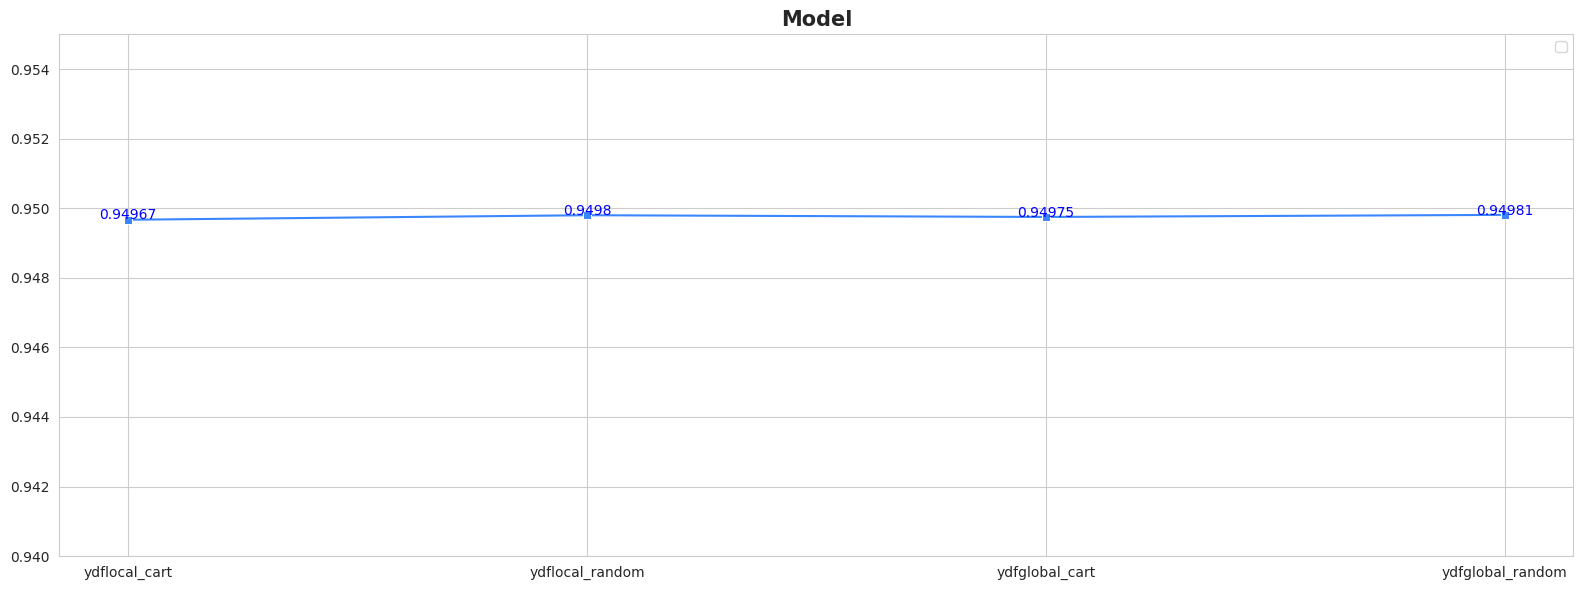

In [43]:
## -- Get Scores --
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax1 = sns.lineplot([*all_scores.values()], marker='s')

y_add = 1e-5

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

plt.ylim((0.94, 0.955))
plt.legend(loc='best')
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title('Model', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

ydflocal_cart_94967 saved!


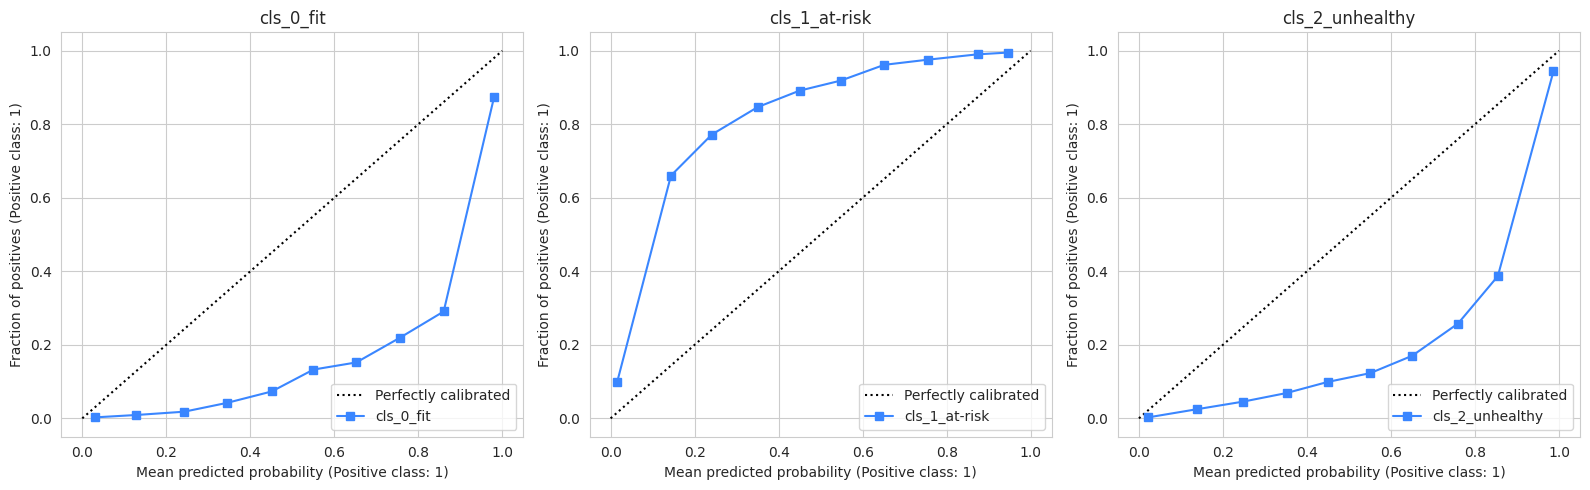

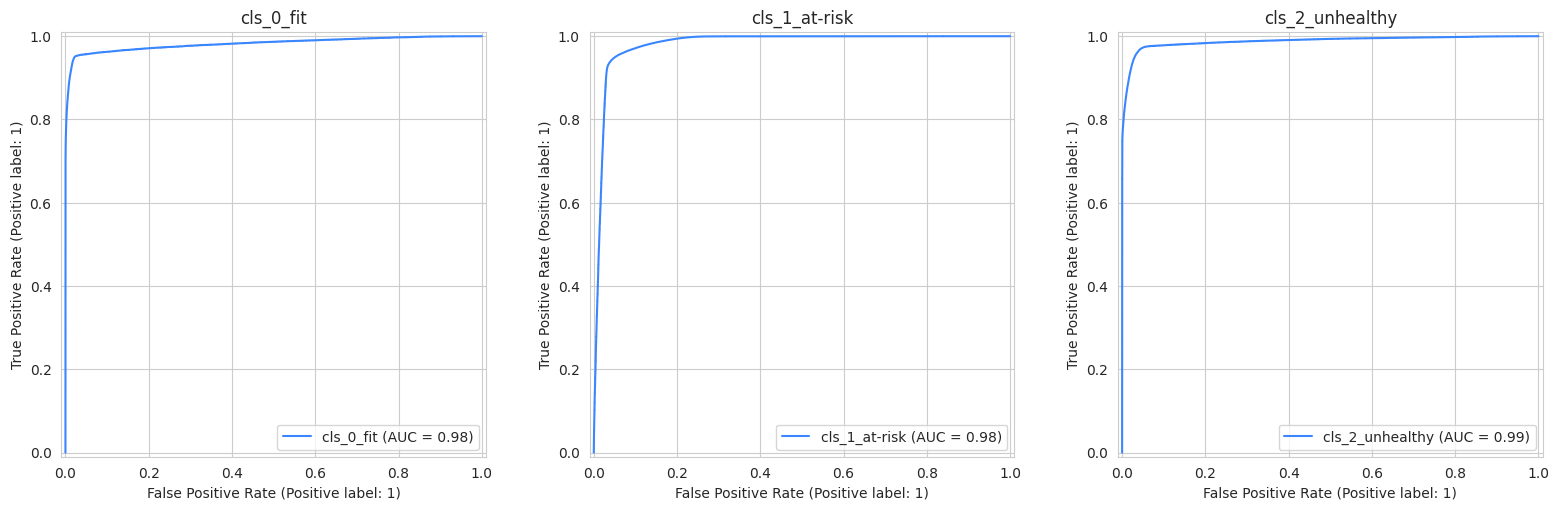


ydflocal_random_9498 saved!


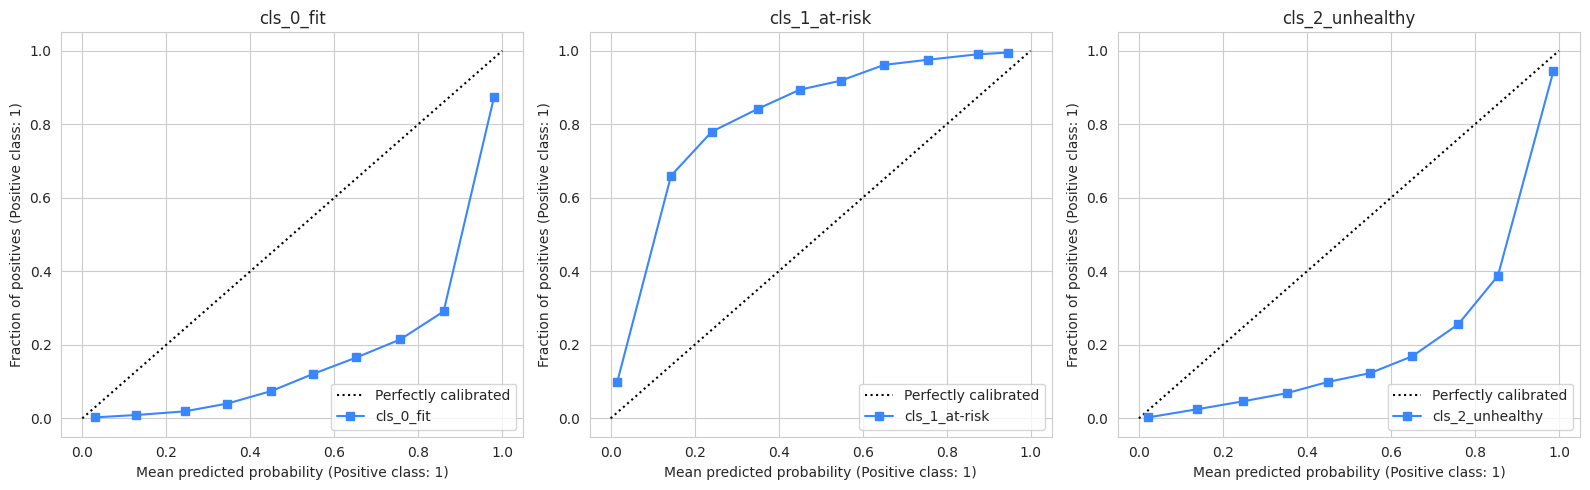

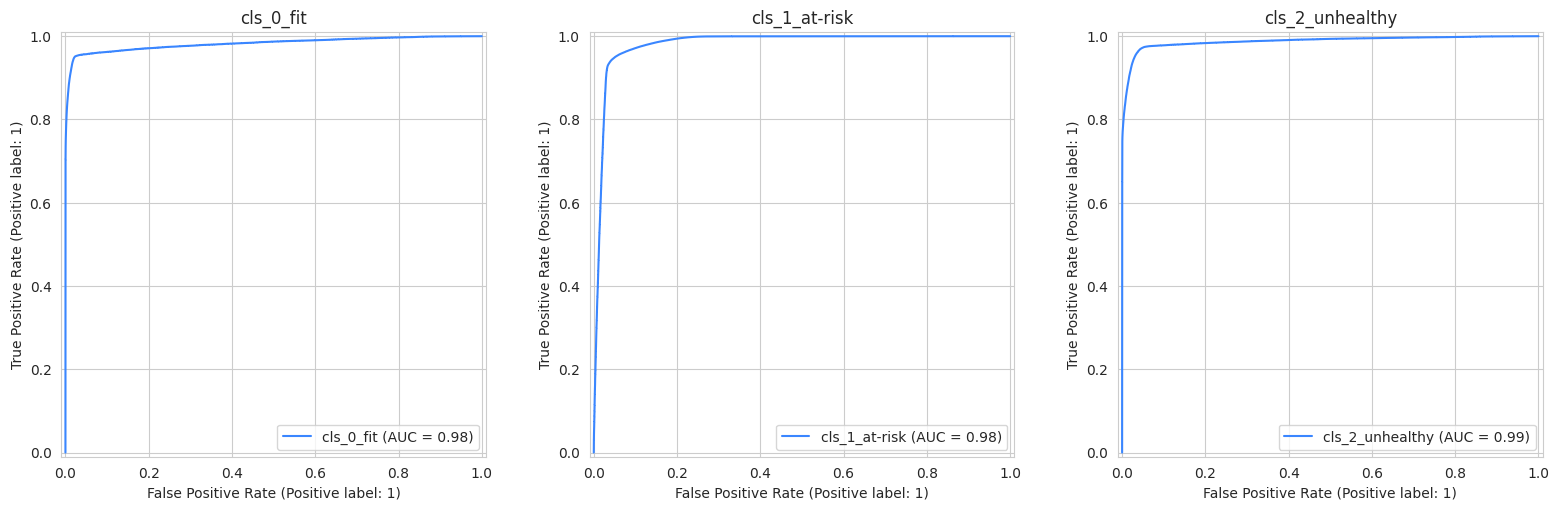


ydfglobal_cart_94975 saved!


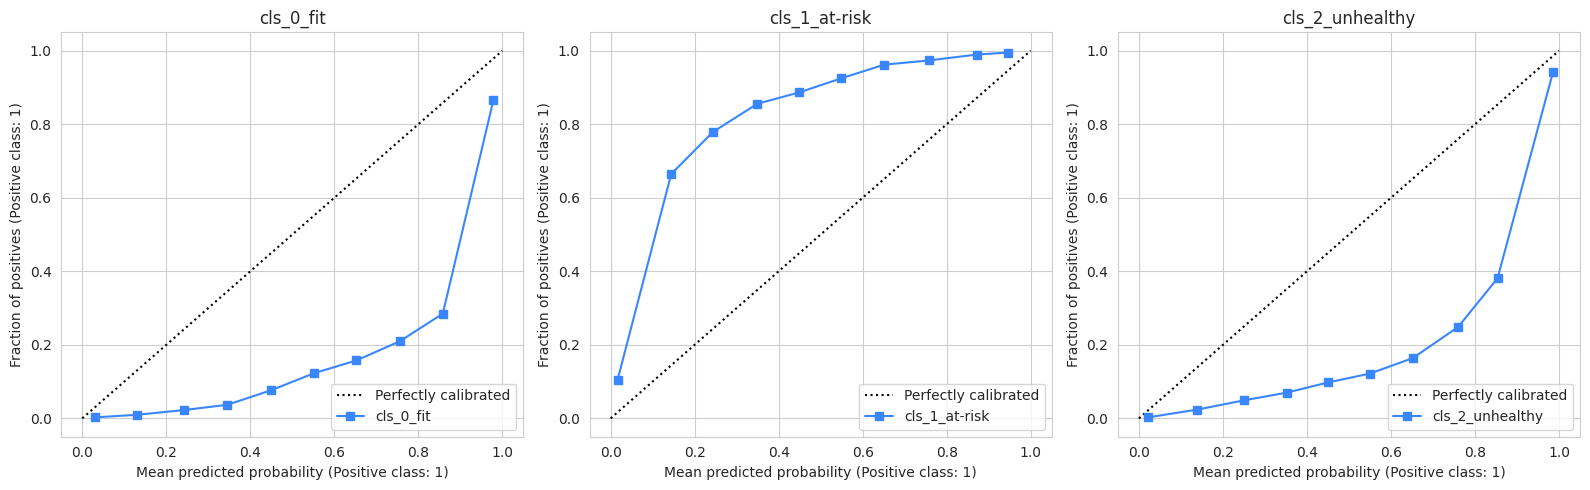

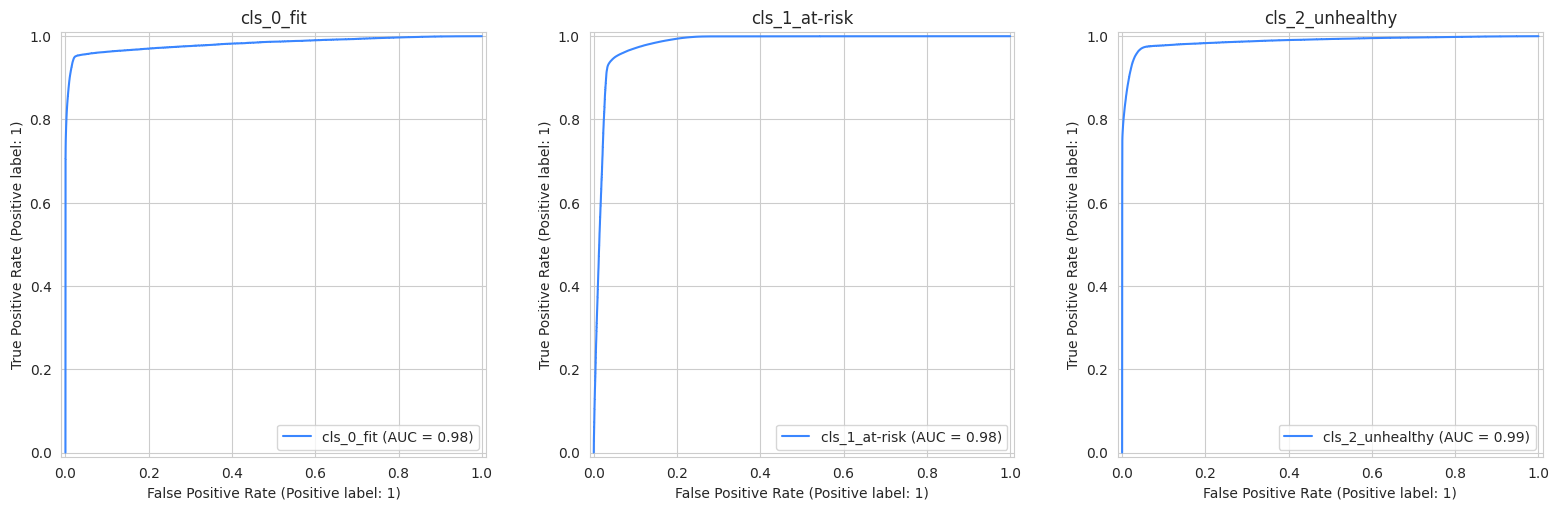


ydfglobal_random_94981 saved!


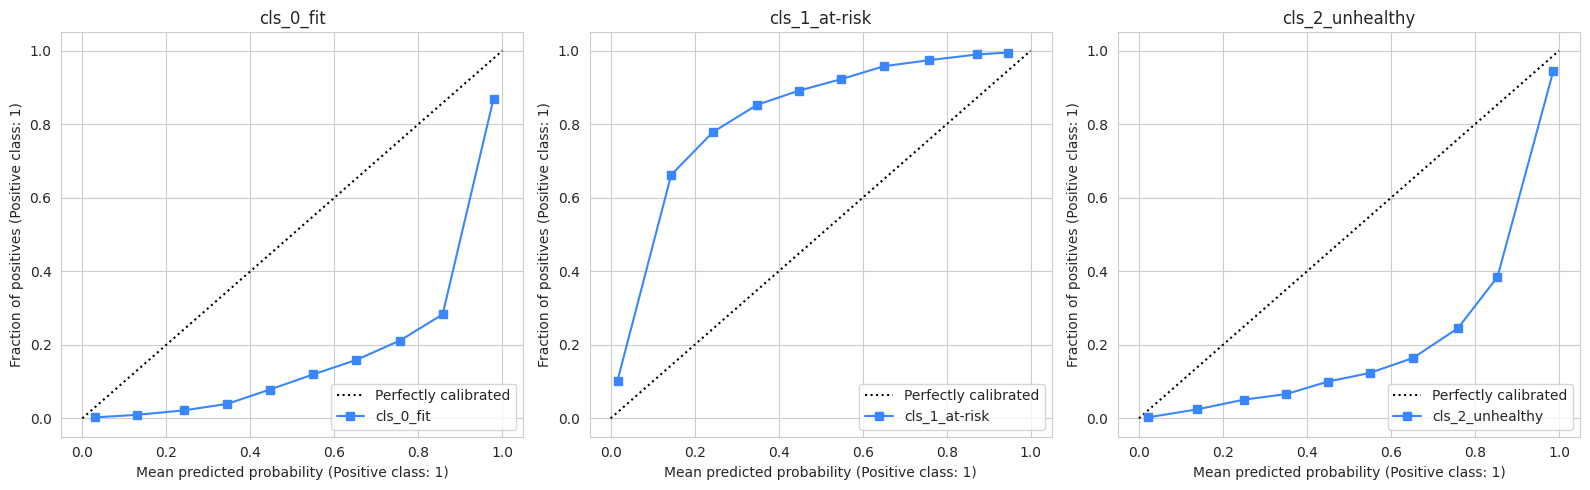

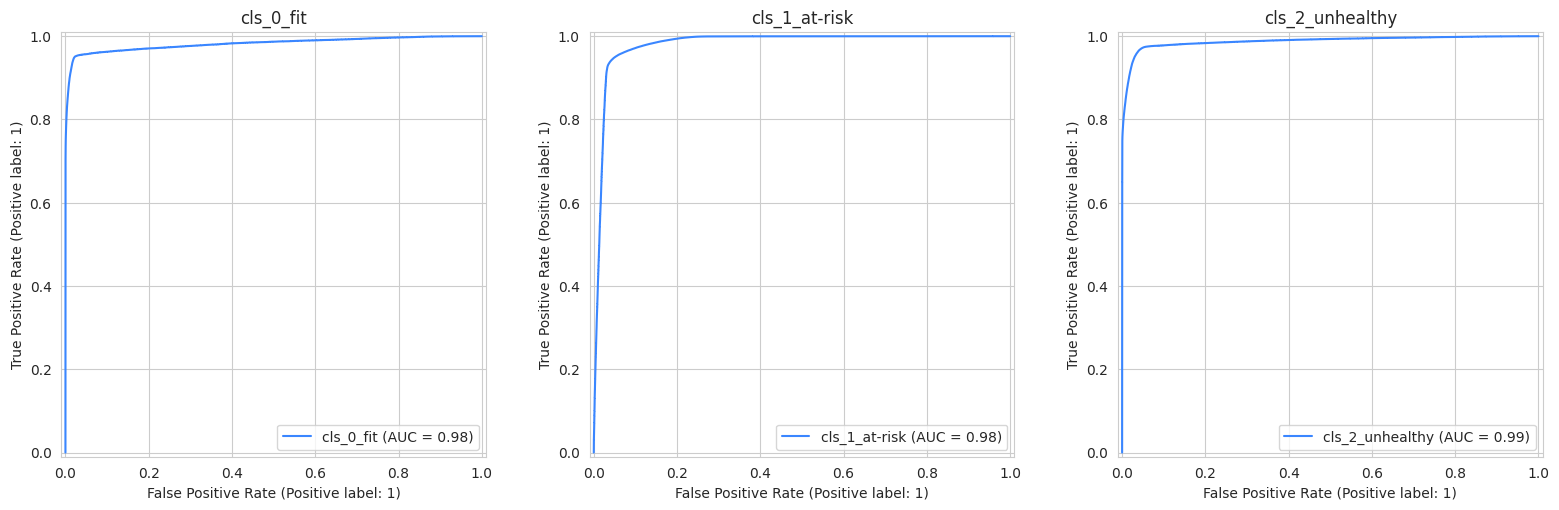

In [44]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

ydflocal_cart_94967 saved! (295753, 3)


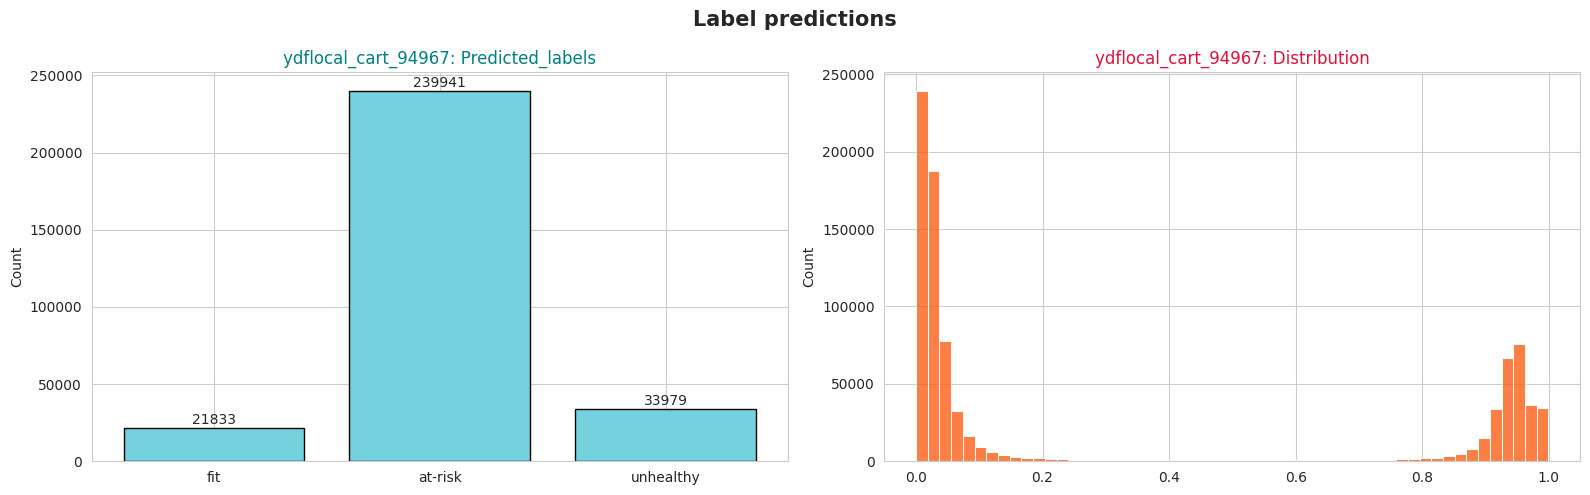


ydflocal_random_9498 saved! (295753, 3)


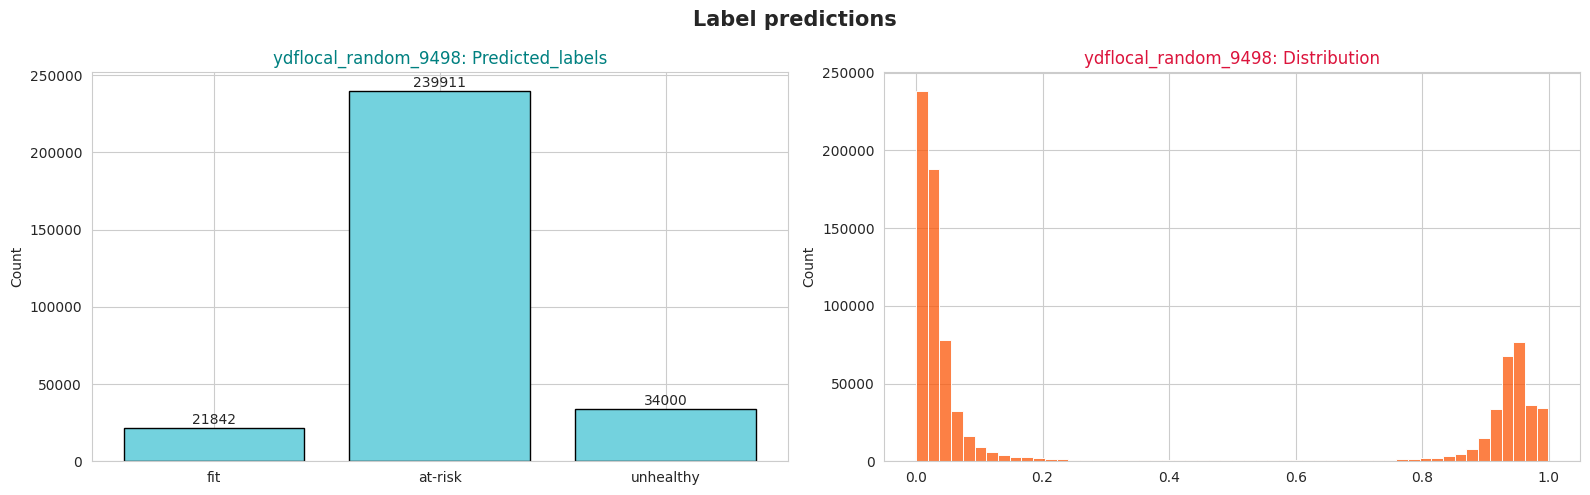


ydfglobal_cart_94975 saved! (295753, 3)


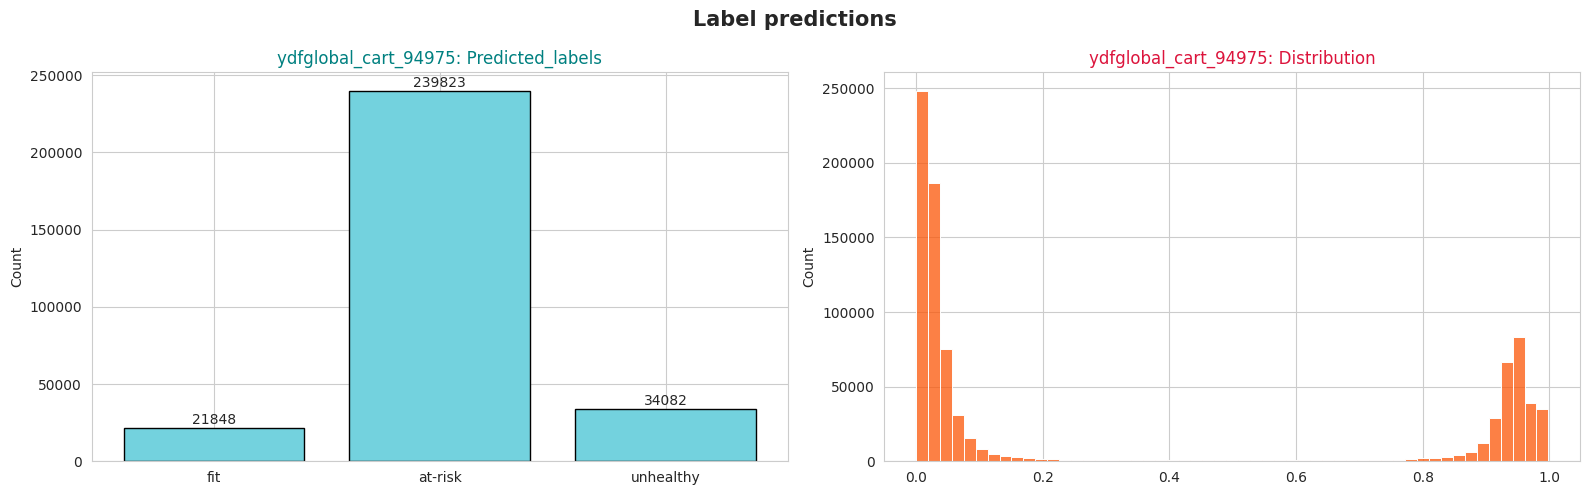


ydfglobal_random_94981 saved! (295753, 3)


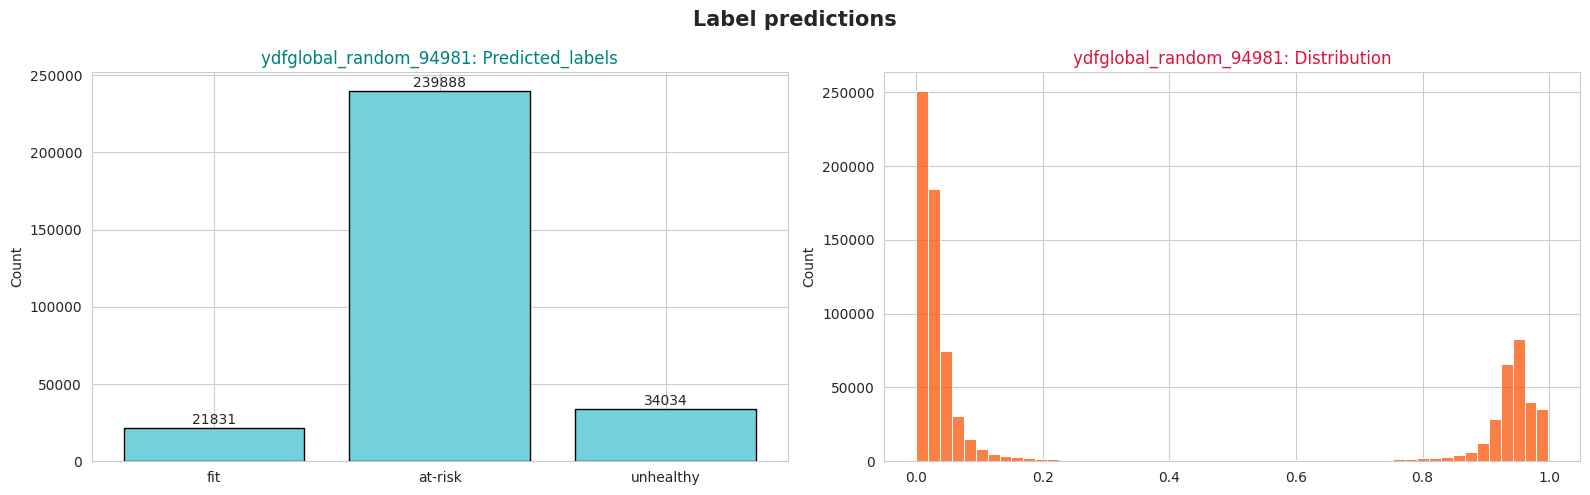

In [45]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [46]:
pd.DataFrame(model_results)

,ydflocal_cart_94967,ydflocal_random_9498,ydfglobal_cart_94975,ydfglobal_random_94981
0,unhealthy,unhealthy,unhealthy,unhealthy
1,unhealthy,unhealthy,unhealthy,unhealthy
2,at-risk,at-risk,at-risk,at-risk
3,at-risk,at-risk,at-risk,at-risk
4,unhealthy,unhealthy,unhealthy,unhealthy
...,...,...,...,...
295748,fit,fit,fit,fit
295749,at-risk,at-risk,at-risk,at-risk
295750,unhealthy,unhealthy,unhealthy,unhealthy
295751,at-risk,at-risk,at-risk,at-risk


In [47]:
# try:
#     import shap
# except:
#     %pip install -q -U shap
#     import shap

# print(f"Shap version: {shap.__version__}")

In [48]:
# ## -- SHAP values: Feature Importances--
# knn_uni = all_predictions[list(all_predictions.keys())[0]]
# mlp_ann = all_predictions[list(all_predictions.keys())[-1]]
# max_display = 20

# for i, m in enumerate([knn_uni, mlp_ann]):
#     model = m['model']
#     x_train = m['data'][0]
#     x_train = m['data'][1]

#     ## -- Shap Explainer --
#     def f(x):
#         return model.predict_proba(x)[:, 1]

#     x_med = x_train.median().values.reshape((1, x_train.shape[1]))
#     explainer = shap.Explainer(f, x_med)
#     explanation = explainer(x_valid.iloc[:1000])

#     ## -- Bar plot --
#     plt.subplot(121)
#     shap.plots.bar(explanation[0], max_display=max_display, show=False)
#     plt.title('Bar - Overall impact on model predictions')
    
#     ## -- Beeswarm plot --
#     plt.subplot(122)
#     shap.plots.beeswarm(explanation, order=explanation.abs.max(0), plot_size=(18, 8),
#                         max_display=max_display, color_bar=False, show=False)
#     plt.title('Beeswarm - Most impactful features')

#     if i == 0:
#         plt.suptitle(list(all_predictions.keys())[i], fontweight='semibold')
#     else:
#         plt.suptitle(list(all_predictions.keys())[-1], fontweight='semibold')

#     plt.tight_layout(pad=1.5)
#     plt.show()
#     print()

In [49]:
## -- Inspect model --
all_data   = []
all_models = []

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'data':
            all_data.append(y)
        elif x == 'model':
            all_models.append(y)

print(f"⚙️ Inspecting first YDF model...\n")
all_models[0].analyze(all_data[0])

⚙️ Inspecting first YDF model...

